# This file makes correlation plots for different variables

author: Eike E. Köhn ......
date: July 29, 2025 ......
instructions: can be run with environment "conda env:pangeo-meso-2024.01.22" on spirit1

## Import packages

In [1]:
print('Loading packages...')
import sys
sys.path.append('../00_modules/.')
from import_packages import PackageGetter
globals().update(PackageGetter.import_standard_packages_for_analysis_and_plotting())
globals().update(PackageGetter.import_custom_packages(import_spline=False))
misc_params = Params.additional_misc_params()

Loading packages...


## Decide if figures are to be saved (and if so the directory)

In [2]:
savefigs = False
plot_dir = Plotter._get_plot_dir('standard')

## Set the parameters for the analysis of the 1pctCO2-cdr run

In [3]:
print('Setting parameters...')
run_params = Params.standard_set_1pctCO2cdr() #Params.test_set_1pctCO2cdr()  #

Setting parameters...


## Choose the variables

In [4]:
print('Choosing variable and temporal resolution....')
variable_to_analyze = ['omegaa','AMOC_40N','sCT','sCT_equilibrium','siconc_son_means']
region_of_choice = 'central Arctic'

Choosing variable and temporal resolution....


## Define required functions

In [5]:
def _get_dataset(variable_to_analyze,region,variable_type):
    data_dir = '../05_plots_datasets/'

    if variable_to_analyze == 'omegaa':
        fignum = '01'
    else:
        fignum = '04'
    if variable_to_analyze == 'AMOC_40N':
        region = ''
    else:
        region += '_'
        
    file_name = f'fig{fignum}_{variable_to_analyze}_{region}{variable_type}.nc'
    return xr.open_dataset(data_dir+file_name)

def _make_correlation_plot(run_params,
                           xvariable,xvariable_name,xvariable_unit,xregion,xvariable_type,
                           yvariable,yvariable_name,yvariable_unit,yregion,yvariable_type,
                           panellabel = 'a)',                                      
                           panellabelloc=[0.5,0.5],correlation_loc=[0.5,0.5],
                           include_correlation_under_exclusion_of = None,
                           correlation_loc2 = [0.5,0.5]):

    ds_x = _get_dataset(xvariable,xregion,xvariable_type)
    ds_y = _get_dataset(yvariable,yregion,yvariable_type)

    fontsize=15
    plt.rcParams['font.size']=fontsize
    fig,ax = plt.subplots(figsize=(4.2,4.2))#,sharey=True)

    xvals = []
    yvals = []
    for key in run_params.keys():
        ax.scatter(ds_x[key],ds_y[key],200,run_params[key].runcol,zorder=2,label=run_params[key].model)#,colors=
        xvals.append(ds_x[key].values)
        yvals.append(ds_y[key].values)

    ax.grid(alpha=0.25)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

    #set the x and y labels
    if xvariable_type == 'normalized_hysteresis_area':
        ax.set_xlabel(f'H$_n$({xvariable_name}) in ppm')
    elif xvariable_type == 'signed_hysteresis_area':
        ax.set_xlabel(f'H$_s$({xvariable_name}) in {xvariable_unit}')
    elif xvariable_type == 'rampdown_means_2nd_half':
        ax.set_xlabel(f'{xvariable_name} in {xvariable_unit}')

    else:
        raise Exception('hysteresis type not known.')
        
    if yvariable_type == 'normalized_hysteresis_area':
        ax.set_ylabel(f'H$_n$({yvariable_name}) in ppm')
    elif yvariable_type == 'signed_hysteresis_area':
        ax.set_ylabel(f'H$_s$({yvariable_name}) in {yvariable_unit}') 
    elif yvariable_type == 'rampdown_means_2nd_half':
        ax.set_ylabel(f'{yvariable_name} in {yvariable_unit}')
    else:
        raise Exception('hysteresis type not known.')

    # include the correlation line
    slope, intercept, r_value, p_value, std_err = spstats.linregress(xvals, yvals)
    ax.plot(np.sort(xvals),intercept+np.sort(xvals)*slope,color='k',linewidth=3,zorder=1)

    # add text
    xpos,ypos = panellabelloc
    ax.text(xpos,ypos,panellabel,transform=ax.transAxes,fontsize=fontsize+2)
    xpos,ypos = correlation_loc
    ax.text(xpos,ypos,f'r={r_value:.2f} (p={p_value:.2f})',transform=ax.transAxes)

    # 
    if include_correlation_under_exclusion_of is not None:
        if isinstance(include_correlation_under_exclusion_of,str):
            exclusion_list = [include_correlation_under_exclusion_of]
        elif isinstance(include_correlation_under_exclusion_of,list):
            exclusion_list = include_correlation_under_exclusion_of
        else:
            raise Exception('include_correlation_under_exclusion_of needs to be a string or list')

        xvals2 = []
        yvals2 = []
        for key in run_params.keys():
            if run_params[key].model not in exclusion_list:
                xvals2.append(ds_x[key].values)
                yvals2.append(ds_y[key].values)

        # include the correlation line
        slope2, intercept2, r_value2, p_value2, std_err2 = spstats.linregress(xvals2, yvals2)
        linecolor = 'g'
        if len(exclusion_list)==1:
            for key in run_params.keys():
                model = run_params[key].model
                if model == exclusion_list[0]:
                    linecolor = run_params[key].runcol            
        ax.plot(np.sort(xvals2),intercept2+np.sort(xvals2)*slope2,color=linecolor,linewidth=3,zorder=1,linestyle='--')
        
        xpos2,ypos2 = correlation_loc2
        ax.text(xpos2,ypos2,f'r={r_value2:.2f} (p={p_value2:.2f})',transform=ax.transAxes,color=linecolor)
    
    return fig,ax
    

## Make the plots

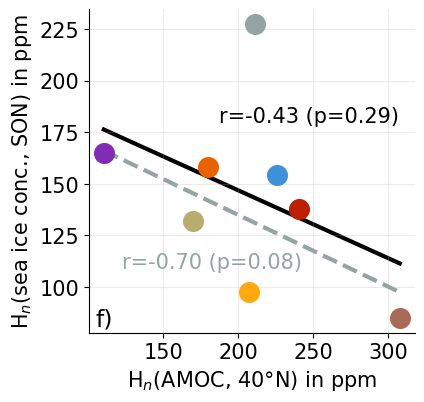

In [6]:
fig,ax = _make_correlation_plot(run_params,
                        'AMOC_40N',r'AMOC, 40°N','Sv',region_of_choice,'normalized_hysteresis_area',
                        'siconc_son_means',r'sea ice conc., SON','-',region_of_choice,'normalized_hysteresis_area',
                         panellabel = 'f)',                                      
                         panellabelloc = [0.02,0.02],
                         correlation_loc = [0.4,0.65],
                         include_correlation_under_exclusion_of='CNRM-ESM2-1',
                         correlation_loc2 = [0.1,0.2])


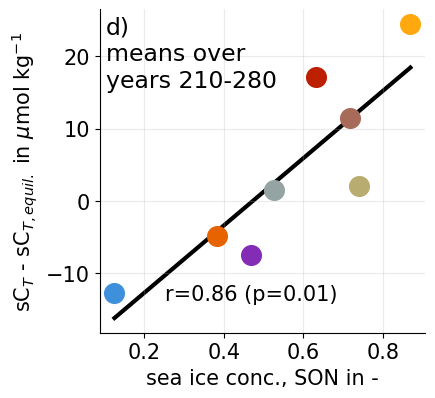

In [7]:
fig,ax = _make_correlation_plot(run_params,
                        'siconc_son_means',r'sea ice conc., SON','-',region_of_choice,'rampdown_means_2nd_half',
                        'sCT_disequilibrium',r'sC$_T$ - sC$_{T,equil.}$',r'$\mu$mol kg$^{-1}$',region_of_choice,'rampdown_means_2nd_half',
                         panellabel = 'd)\nmeans over\nyears 210-280',                                      
                         panellabelloc = [0.02,0.76],
                         correlation_loc = [0.2,0.1])


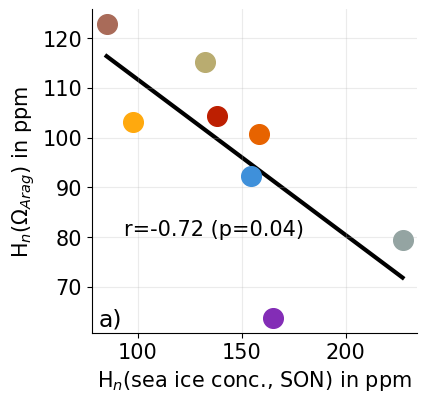

In [12]:
fig,ax = _make_correlation_plot(run_params,
                        'siconc_son_means',r'sea ice conc., SON','-',region_of_choice,'normalized_hysteresis_area',
                        'omegaa',r'$\Omega_{Arag}$','-',region_of_choice,'normalized_hysteresis_area',
                         panellabel = 'a)',                                      
                         panellabelloc = [0.02,0.02],
                         correlation_loc = [0.1,0.3])


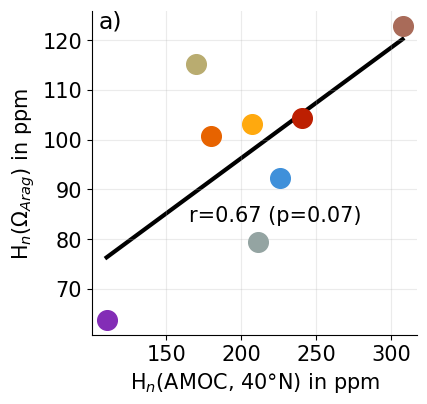

In [15]:
fig,ax = _make_correlation_plot(run_params,
                        'AMOC_40N',r'AMOC, 40°N','Sv',region_of_choice,'normalized_hysteresis_area',
                        'omegaa',r'$\Omega_{Arag}$','-',region_of_choice,'normalized_hysteresis_area',
                         panellabel = 'a)',                                      
                         panellabelloc = [0.02,0.95],
                         correlation_loc = [0.3,0.35])

## Plot a legend

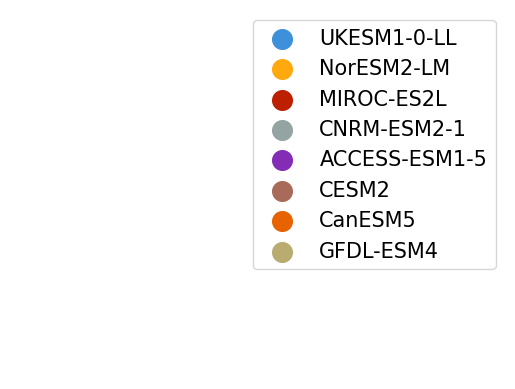

In [19]:
fig, ax = plt.subplots()
for key in run_params.keys():
    ax.scatter(0,0,200,run_params[key].runcol,label=run_params[key].model)
ax.set_xlim([10,20]);ax.set_ylim([10,20])
plt.gca().set_axis_off()
plt.legend()